# Module 2 — Emotional Trajectory Tracker

**Conversational Emotional Trajectory Modeling & Adaptive Dialogue System**

This notebook implements **Module 2** of the NLP project architecture. It accepts per-turn multi-label emotion predictions from an upstream RoBERTa/DeBERTa classifier and computes higher-order emotional signals across the full conversation.

### Outputs
| Signal | Description |
|---|---|
| **Emotional Momentum** | Exponentially-weighted directional drift in valence |
| **Volatility Index** | Normalised standard deviation of per-turn intensity |
| **Escalation Score** | Regression slope of negative-affect activation |
| **Dominant Emotional State** | Recency-weighted dominant cluster across turns |
| **Transition Matrix** | Row-normalised bigram probabilities over emotion sequence |
| **Emotion State Graph** | Weighted `networkx.DiGraph` of emotion transitions |

### Compatible Datasets
- **GoEmotions** — multi-label fine-grained classification (28 labels)
- **DailyDialog** — 7-class emotion labels per utterance
- **MELD** — emotion + sentiment strings from Friends dialogue
- **EmpatheticDialogues** — situation-level emotion labels

## 0. Install Dependencies

In [1]:
# Uncomment and run if needed
# !pip install networkx matplotlib numpy

## 1. Imports & Emotion Taxonomy

In [2]:
from __future__ import annotations

import math
from collections import defaultdict
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

print("All imports successful.")

All imports successful.


In [3]:
# ---------------------------------------------------------------------------
# Emotion taxonomy
# Maps fine-grained RoBERTa labels → 7 core clusters (Ekman + Contempt)
# ---------------------------------------------------------------------------

EMOTION_CLUSTERS: Dict[str, str] = {
    # Joy
    "joy": "Joy", "happiness": "Joy", "excitement": "Joy", "amusement": "Joy",
    "gratitude": "Joy", "love": "Joy", "pride": "Joy", "relief": "Joy", "optimism": "Joy",
    # Sadness
    "sadness": "Sadness", "grief": "Sadness", "disappointment": "Sadness",
    "loneliness": "Sadness", "melancholy": "Sadness",
    # Anger
    "anger": "Anger", "frustration": "Anger", "annoyance": "Anger",
    "rage": "Anger", "resentment": "Anger",
    # Fear
    "fear": "Fear", "anxiety": "Fear", "nervousness": "Fear", "stress": "Fear",
    "worry": "Fear", "panic": "Fear", "dread": "Fear", "apprehension": "Fear",
    "self-doubt": "Fear", "pressure": "Fear", "overwhelm": "Fear",
    # Disgust
    "disgust": "Disgust", "contempt": "Disgust", "revulsion": "Disgust",
    # Surprise
    "surprise": "Surprise", "shock": "Surprise", "amazement": "Surprise",
    # Contempt (kept separate per proposal)
    "contempt": "Contempt", "disdain": "Contempt", "scorn": "Contempt",
}

# Dimensional affect scores per cluster
VALENCE: Dict[str, float] = {
    "Joy": +1.0, "Surprise": +0.2,
    "Sadness": -0.7, "Fear": -0.8, "Anger": -0.9,
    "Disgust": -0.85, "Contempt": -0.6,
}
AROUSAL: Dict[str, float] = {
    "Joy": 0.7, "Surprise": 0.9,
    "Sadness": 0.3, "Fear": 0.85, "Anger": 0.95,
    "Disgust": 0.6, "Contempt": 0.5,
}

CLUSTER_COLORS = {
    "Joy": "#4CAF50", "Fear": "#FF9800", "Anger": "#F44336",
    "Sadness": "#2196F3", "Disgust": "#795548",
    "Surprise": "#E91E63", "Contempt": "#9C27B0",
}

print("Taxonomy loaded:", list(VALENCE.keys()))

Taxonomy loaded: ['Joy', 'Surprise', 'Sadness', 'Fear', 'Anger', 'Disgust', 'Contempt']


## 2. Data Containers

In [4]:
@dataclass
class TurnSnapshot:
    """
    Per-utterance emotional state derived from the upstream RoBERTa classifier.

    Parameters
    ----------
    turn_idx : int
        0-based index of this turn in the conversation.
    raw_emotions : dict
        Direct output from classifier, e.g. {"Anxiety": 0.72, "Stress": 0.81}.
    """
    turn_idx: int
    raw_emotions: Dict[str, float]
    clustered: Dict[str, float] = field(default_factory=dict)
    dominant: str = ""
    intensity: float = 0.0   # mean of raw scores
    valence: float = 0.0     # weighted valence in [-1, 1]
    arousal: float = 0.0     # weighted arousal in [0, 1]

    def __post_init__(self) -> None:
        self._cluster_emotions()

    def _cluster_emotions(self) -> None:
        """Map fine-grained labels to core clusters and compute affect dimensions."""
        acc: Dict[str, float] = defaultdict(float)
        for label, score in self.raw_emotions.items():
            cluster = EMOTION_CLUSTERS.get(label.lower(), label.title())
            acc[cluster] += score

        total = sum(acc.values()) or 1.0
        self.clustered = {k: v / total for k, v in acc.items()}
        self.dominant = max(self.clustered, key=self.clustered.get)
        self.intensity = float(np.mean(list(self.raw_emotions.values())))

        v, a, w = 0.0, 0.0, 0.0
        for cluster, weight in self.clustered.items():
            v += VALENCE.get(cluster, 0.0) * weight
            a += AROUSAL.get(cluster, 0.0) * weight
            w += weight
        if w:
            self.valence = round(v / w, 4)
            self.arousal = round(a / w, 4)

    def __repr__(self) -> str:
        return (f"TurnSnapshot(turn={self.turn_idx}, dominant={self.dominant!r}, "
                f"intensity={self.intensity:.3f}, valence={self.valence:+.3f}, "
                f"arousal={self.arousal:.3f})")


@dataclass
class TrajectorySignals:
    """All higher-order signals computed over a complete conversation."""
    turns: int = 0
    emotional_momentum: float = 0.0
    volatility_index: float = 0.0
    escalation_score: float = 0.0
    dominant_state: str = ""
    transition_matrix: Dict[str, Dict[str, float]] = field(default_factory=dict)
    emotion_sequence: List[str] = field(default_factory=list)
    intensity_series: List[float] = field(default_factory=list)
    valence_series: List[float] = field(default_factory=list)
    arousal_series: List[float] = field(default_factory=list)
    snapshots: List[TurnSnapshot] = field(default_factory=list)

    def summary(self) -> str:
        lines = [
            "═" * 56,
            "  EMOTIONAL TRAJECTORY SUMMARY",
            "═" * 56,
            f"  Turns analysed     : {self.turns}",
            f"  Dominant state     : {self.dominant_state}",
            f"  Emotional momentum : {self.emotional_momentum:+.4f}",
            f"  Volatility index   : {self.volatility_index:.4f}",
            f"  Escalation score   : {self.escalation_score:+.4f}",
            "",
            "  Emotion sequence   : " + " → ".join(self.emotion_sequence),
            "",
            "  Turn-by-turn detail:",
        ]
        for snap in self.snapshots:
            raw_str = ", ".join(f"{k}({v:.2f})" for k, v in snap.raw_emotions.items())
            lines.append(
                f"    T{snap.turn_idx+1}: [{raw_str}]  "
                f"→ {snap.dominant}  "
                f"intensity={snap.intensity:.3f}  "
                f"valence={snap.valence:+.3f}  "
                f"arousal={snap.arousal:.3f}"
            )
        lines += ["", "  Transition probabilities:"]
        for src, targets in self.transition_matrix.items():
            for tgt, prob in sorted(targets.items(), key=lambda x: -x[1]):
                if prob > 0:
                    lines.append(f"    {src:<12} → {tgt:<12}  p={prob:.2f}")
        lines.append("═" * 56)
        return "\n".join(lines)

print("Data containers defined.")

Data containers defined.


## 3. Emotional Trajectory Tracker

In [5]:
class EmotionalTrajectoryTracker:
    """
    Module 2 — stateful tracker for higher-order emotional signals.

    Usage
    -----
    tracker = EmotionalTrajectoryTracker()
    tracker.add_turn({"Anxiety": 0.72, "Stress": 0.81})
    tracker.add_turn({"Anxiety": 0.85, "Self-doubt": 0.76})
    tracker.add_turn({"Pressure": 0.89, "Frustration": 0.67})
    signals = tracker.compute()
    print(signals.summary())

    Parameters
    ----------
    window : int
        Rolling window size for momentum / escalation (default 3).
    """

    def __init__(self, window: int = 3) -> None:
        self.window = window
        self._snapshots: List[TurnSnapshot] = []

    # ── Public API ────────────────────────────────────────────────────────────

    def add_turn(self, emotions: Dict[str, float]) -> TurnSnapshot:
        """Ingest a single turn's emotion predictions and return its snapshot."""
        snap = TurnSnapshot(
            turn_idx=len(self._snapshots),
            raw_emotions={k: float(v) for k, v in emotions.items()},
        )
        self._snapshots.append(snap)
        return snap

    def reset(self) -> None:
        """Clear all stored turns."""
        self._snapshots.clear()

    def compute(self) -> TrajectorySignals:
        """Compute all higher-order signals over the accumulated turns."""
        n = len(self._snapshots)
        if n == 0:
            raise ValueError("No turns added yet — call add_turn() first.")

        signals = TrajectorySignals(
            turns=n,
            snapshots=list(self._snapshots),
        )

        signals.emotion_sequence = [s.dominant for s in self._snapshots]
        signals.intensity_series = [s.intensity for s in self._snapshots]
        signals.valence_series   = [s.valence   for s in self._snapshots]
        signals.arousal_series   = [s.arousal   for s in self._snapshots]

        # Recency-weighted dominant state
        cluster_scores: Dict[str, float] = defaultdict(float)
        for i, snap in enumerate(self._snapshots):
            weight = (i + 1) / n
            for cluster, score in snap.clustered.items():
                cluster_scores[cluster] += score * weight
        signals.dominant_state = max(cluster_scores, key=cluster_scores.get)

        signals.emotional_momentum = self._compute_momentum(signals.valence_series)
        signals.volatility_index   = self._compute_volatility(signals.intensity_series)
        signals.escalation_score   = self._compute_escalation(
            signals.valence_series, signals.arousal_series
        )
        signals.transition_matrix  = self._build_transition_matrix(
            signals.emotion_sequence
        )
        return signals

    # ── Computation helpers ───────────────────────────────────────────────────

    @staticmethod
    def _compute_momentum(valence_series: List[float]) -> float:
        """
        Emotional Momentum = exponentially-weighted mean of first differences in valence.
        Sign indicates direction; magnitude indicates speed.
        Range: [-1, +1]
        """
        if len(valence_series) < 2:
            return 0.0
        diffs = [valence_series[i] - valence_series[i - 1]
                 for i in range(1, len(valence_series))]
        weights = [math.exp(i) for i in range(len(diffs))]
        w_total = sum(weights)
        momentum = sum(d * w for d, w in zip(diffs, weights)) / w_total
        return float(np.clip(momentum, -1.0, 1.0))

    @staticmethod
    def _compute_volatility(intensity_series: List[float]) -> float:
        """
        Volatility Index = standard deviation of per-turn intensities.
        Normalised to [0, 1] (max possible std for Uniform[0,1] ≈ 0.5).
        """
        if len(intensity_series) < 2:
            return 0.0
        std = float(np.std(intensity_series))
        return float(np.clip(std / 0.5, 0.0, 1.0))

    @staticmethod
    def _compute_escalation(
        valence_series: List[float],
        arousal_series: List[float],
    ) -> float:
        """
        Escalation Score = linear regression slope of negative-affect activation,
        defined as: arousal × (1 − (valence + 1) / 2).

        +1.0 → strong escalation toward high-arousal negative states
        -1.0 → de-escalation / calming
         0.0 → stable
        """
        n = len(valence_series)
        if n < 2:
            return 0.0
        neg_activation = [
            ar * (1.0 - (vl + 1.0) / 2.0)
            for vl, ar in zip(valence_series, arousal_series)
        ]
        x = np.arange(n, dtype=float)
        slope, _ = np.polyfit(x, neg_activation, 1)
        return float(np.clip(slope * n, -1.0, 1.0))

    @staticmethod
    def _build_transition_matrix(
        emotion_sequence: List[str],
    ) -> Dict[str, Dict[str, float]]:
        """
        Build a row-normalised transition probability matrix from
        bigrams of the dominant-emotion sequence.
        """
        states = sorted(set(emotion_sequence))
        counts: Dict[str, Dict[str, float]] = {
            s: {t: 0.0 for t in states} for s in states
        }
        for a, b in zip(emotion_sequence, emotion_sequence[1:]):
            counts[a][b] += 1.0
        for src in states:
            total = sum(counts[src].values())
            if total > 0:
                for tgt in states:
                    counts[src][tgt] /= total
        return counts


print("EmotionalTrajectoryTracker defined.")

EmotionalTrajectoryTracker defined.


## 4. Emotion State Graph Builder

In [6]:
def build_emotion_state_graph(signals: TrajectorySignals) -> nx.DiGraph:
    """
    Build a directed weighted graph of emotion transitions.

    Nodes
    -----
    - Each unique dominant emotion cluster seen in the conversation.
    - Node attributes: mean_intensity, count, valence.

    Edges
    -----
    - Directed edge from A → B if A transitioned to B.
    - Edge weight = transition probability from the transition matrix.

    Returns
    -------
    networkx.DiGraph
    """
    G = nx.DiGraph()

    cluster_intensity: Dict[str, List[float]] = defaultdict(list)
    for snap in signals.snapshots:
        cluster_intensity[snap.dominant].append(snap.intensity)

    for cluster, intensities in cluster_intensity.items():
        G.add_node(
            cluster,
            mean_intensity=float(np.mean(intensities)),
            count=len(intensities),
            valence=VALENCE.get(cluster, 0.0),
        )

    for src, targets in signals.transition_matrix.items():
        for tgt, prob in targets.items():
            if prob > 0 and src in G.nodes and tgt in G.nodes:
                G.add_edge(src, tgt, weight=prob)

    return G


print("build_emotion_state_graph() defined.")

build_emotion_state_graph() defined.


## 5. Visualisation

In [7]:
def plot_trajectory(signals: TrajectorySignals, save_path: Optional[str] = None) -> None:
    """
    Four-panel figure:
      1. Intensity & valence across turns
      2. Arousal across turns
      3. Higher-order signal bar chart
      4. Emotion state graph
    """
    fig = plt.figure(figsize=(16, 10), facecolor="#0d0d14")
    fig.suptitle(
        "Emotional Trajectory Analysis — Module 2",
        fontsize=17, fontweight="bold", color="#e8e0f0", y=0.97
    )

    ACCENT = "#b57bee"
    WARN   = "#f0826a"
    CALM   = "#6abed0"
    GRID   = "#1e1e2e"
    TEXT   = "#ccc8e8"

    turns = list(range(1, signals.turns + 1))

    # ── Panel 1: Intensity & Valence ─────────────────────────────────────────
    ax1 = fig.add_subplot(2, 2, 1, facecolor=GRID)
    ax1.plot(turns, signals.intensity_series, "o-", color=ACCENT,
             linewidth=2, markersize=7, label="Intensity", zorder=3)
    ax1v = ax1.twinx()
    ax1v.plot(turns, signals.valence_series, "s--", color=CALM,
              linewidth=1.5, markersize=5, label="Valence", zorder=2)
    ax1v.axhline(0, color="#555", linewidth=0.8, linestyle=":")
    ax1v.set_ylabel("Valence (−1 → +1)", color=CALM, fontsize=9)
    ax1v.tick_params(colors=CALM)
    ax1.set_title("Intensity & Valence per Turn", color=TEXT, fontsize=11, pad=8)
    ax1.set_xlabel("Turn", color=TEXT)
    ax1.set_ylabel("Intensity", color=ACCENT)
    ax1.tick_params(colors=TEXT)
    ax1.set_xticks(turns)
    ax1.set_ylim(0, 1.05)
    for i, (t, snap) in enumerate(zip(turns, signals.snapshots)):
        ax1.annotate(snap.dominant, (t, signals.intensity_series[i]),
                     textcoords="offset points", xytext=(0, 10),
                     ha="center", fontsize=7.5, color=TEXT)
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax1v.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8,
               facecolor="#1a1a2e", labelcolor=TEXT, loc="lower left")
    _style_axes(ax1, TEXT)

    # ── Panel 2: Arousal ─────────────────────────────────────────────────────
    ax2 = fig.add_subplot(2, 2, 2, facecolor=GRID)
    ax2.fill_between(turns, signals.arousal_series, alpha=0.3, color=WARN)
    ax2.plot(turns, signals.arousal_series, "o-", color=WARN, linewidth=2, markersize=7)
    esc = signals.escalation_score
    esc_label = (
        f"Escalation: {esc:+.3f} "
        f"({'↑ escalating' if esc > 0.1 else '↓ de-escalating' if esc < -0.1 else '→ stable'})"
    )
    ax2.text(0.97, 0.05, esc_label, transform=ax2.transAxes,
             ha="right", fontsize=8.5, color=WARN,
             bbox=dict(boxstyle="round,pad=0.4", facecolor="#2a1a1a", edgecolor=WARN, alpha=0.8))
    ax2.set_title("Arousal Trajectory", color=TEXT, fontsize=11, pad=8)
    ax2.set_xlabel("Turn", color=TEXT)
    ax2.set_ylabel("Arousal", color=WARN)
    ax2.tick_params(colors=TEXT)
    ax2.set_xticks(turns)
    ax2.set_ylim(0, 1.05)
    _style_axes(ax2, TEXT)

    # ── Panel 3: Signal bar chart ─────────────────────────────────────────────
    ax3 = fig.add_subplot(2, 2, 3, facecolor=GRID)
    metrics = {
        "Momentum":  signals.emotional_momentum,
        "Volatility": signals.volatility_index,
        "Escalation": signals.escalation_score,
    }
    colors = [CALM if v >= 0 else WARN for v in metrics.values()]
    bars = ax3.barh(list(metrics.keys()), list(metrics.values()),
                    color=colors, height=0.45, edgecolor="#333")
    ax3.axvline(0, color="#888", linewidth=1)
    ax3.set_xlim(-1.1, 1.1)
    ax3.set_title("Higher-Order Signal Scores", color=TEXT, fontsize=11, pad=8)
    ax3.tick_params(colors=TEXT)
    _style_axes(ax3, TEXT)
    for bar, val in zip(bars, metrics.values()):
        ax3.text(
            val + (0.04 if val >= 0 else -0.04),
            bar.get_y() + bar.get_height() / 2,
            f"{val:+.3f}", va="center",
            ha="left" if val >= 0 else "right",
            fontsize=9, color=TEXT
        )

    # ── Panel 4: Emotion State Graph ──────────────────────────────────────────
    ax4 = fig.add_subplot(2, 2, 4, facecolor=GRID)
    G = build_emotion_state_graph(signals)
    if len(G.nodes) > 0:
        _draw_graph(G, ax4, ACCENT, WARN, CALM, TEXT)
    else:
        ax4.text(0.5, 0.5, "Not enough turns for graph",
                 transform=ax4.transAxes, ha="center", va="center",
                 color=TEXT, fontsize=11)
    ax4.set_title("Emotion State Graph", color=TEXT, fontsize=11, pad=8)
    _style_axes(ax4, TEXT)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight",
                    facecolor=fig.get_facecolor())
        print(f"Saved → {save_path}")
    plt.show()


def _draw_graph(G, ax, ACCENT, WARN, CALM, TEXT) -> None:
    pos = nx.spring_layout(G, seed=42, k=2.5)
    node_sizes  = [G.nodes[n].get("mean_intensity", 0.5) * 2500 + 600 for n in G.nodes]
    node_colors = [
        CLUSTER_COLORS.get(n, WARN) for n in G.nodes
    ]
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_sizes,
                           node_color=node_colors, alpha=0.85)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=8,
                            font_color=TEXT, font_weight="bold")
    edges   = list(G.edges(data=True))
    weights = [d.get("weight", 0.1) for _, _, d in edges]
    widths  = [max(1.0, w * 4) for w in weights]
    edge_cols = [ACCENT if w > 0.5 else "#888" for w in weights]
    nx.draw_networkx_edges(G, pos, ax=ax, width=widths, edge_color=edge_cols,
                           arrows=True, arrowsize=18, alpha=0.85,
                           connectionstyle="arc3,rad=0.2",
                           min_source_margin=20, min_target_margin=20)
    edge_labels = {(u, v): f"{d['weight']:.2f}"
                   for u, v, d in G.edges(data=True) if d.get("weight", 0) > 0.1}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax,
                                 font_size=7, font_color="#ccc")


def _style_axes(ax, text_color: str) -> None:
    for spine in ax.spines.values():
        spine.set_edgecolor("#333")
    ax.tick_params(colors=text_color)
    ax.xaxis.label.set_color(text_color)
    ax.yaxis.label.set_color(text_color)


print("Visualisation functions defined.")

Visualisation functions defined.


## 6. Dataset Adapters

Thin adapters to convert raw rows from each supported dataset into the `Dict[str, float]` format expected by `EmotionalTrajectoryTracker.add_turn()`.

In [8]:
class DatasetAdapters:
    """
    Converts raw dataset rows into Dict[str, float] for the tracker.

    All public methods are static and return a single-turn emotion dict.
    To build a full conversation, iterate over utterances and call
    tracker.add_turn(adapter_method(...)) for each one.
    """

    # GoEmotions 28-class label index order
    GOEMOTION_LABELS = [
        "admiration", "amusement", "anger", "annoyance", "approval", "caring",
        "confusion", "curiosity", "desire", "disappointment", "disapproval",
        "disgust", "embarrassment", "excitement", "fear", "gratitude", "grief",
        "joy", "love", "nervousness", "optimism", "pride", "realization",
        "relief", "remorse", "sadness", "surprise", "neutral",
    ]

    @staticmethod
    def from_goemotion_logits(
        logits: List[float],
        threshold: float = 0.3
    ) -> Dict[str, float]:
        """
        GoEmotions — use raw sigmoid probabilities (28-dim vector).
        Labels with probability >= threshold are included.

        Example
        -------
        >>> logits = [0.05] * 28
        >>> logits[14] = 0.82  # fear
        >>> logits[19] = 0.61  # nervousness
        >>> DatasetAdapters.from_goemotion_logits(logits)
        {'fear': 0.82, 'nervousness': 0.61}
        """
        labels = DatasetAdapters.GOEMOTION_LABELS
        return {
            labels[i]: float(p)
            for i, p in enumerate(logits)
            if p >= threshold and i < len(labels)
        }

    @staticmethod
    def from_goemotion_indices(
        label_indices: List[int],
        score: float = 0.8
    ) -> Dict[str, float]:
        """
        GoEmotions — binary multi-label format (list of active label indices).
        Assigns a uniform `score` to each present label.
        """
        labels = DatasetAdapters.GOEMOTION_LABELS
        return {labels[i]: score for i in label_indices if i < len(labels)}

    @staticmethod
    def from_dailydialog(emotion_id: int, intensity: float = 0.75) -> Dict[str, float]:
        """
        DailyDialog — 7-class integer label.
        0=no_emotion, 1=anger, 2=disgust, 3=fear, 4=happiness, 5=sadness, 6=surprise.

        Returns an empty dict for no_emotion (neutral turns).

        Example
        -------
        >>> DatasetAdapters.from_dailydialog(3)
        {'Fear': 0.75}
        """
        mapping = {
            0: {},
            1: {"Anger":   intensity},
            2: {"Disgust": intensity},
            3: {"Fear":    intensity},
            4: {"Joy":     intensity},
            5: {"Sadness": intensity},
            6: {"Surprise":intensity},
        }
        return mapping.get(emotion_id, {})

    @staticmethod
    def from_meld(emotion: str, sentiment: str) -> Dict[str, float]:
        """
        MELD — emotion string + sentiment string.
        Combines both into a single emotion dict with a small sentiment boost.

        Example
        -------
        >>> DatasetAdapters.from_meld("fear", "negative")
        {'fear': 0.75, 'Sadness': 0.2}
        """
        base = {emotion.lower(): 0.75}
        sentiment_boost = {
            "positive": {"Joy":     0.3},
            "negative": {"Sadness": 0.2},
            "neutral":  {},
        }
        base.update(sentiment_boost.get(sentiment.lower(), {}))
        return base

    @staticmethod
    def from_empathetic(emotion_label: str, score: float = 0.8) -> Dict[str, float]:
        """
        EmpatheticDialogues — situation-level emotion string.
        In practice, pair with RoBERTa scores from the utterance text.

        Example
        -------
        >>> DatasetAdapters.from_empathetic("afraid")
        {'afraid': 0.8}
        """
        return {emotion_label.lower(): score}


print("DatasetAdapters defined.")

DatasetAdapters defined.


## 7. Demo — Proposal Example Conversation

Replicates the three-turn example from the project proposal:

> *"I'm really stressed about my exam tomorrow."*  
> *"I studied but I feel like I'm going to mess everything up."*  
> *"My parents are expecting too much."*

In [9]:
tracker = EmotionalTrajectoryTracker(window=3)

# Turn 1: "I'm really stressed about my exam tomorrow."
t1 = tracker.add_turn({"Anxiety": 0.72, "Stress": 0.81})

# Turn 2: "I studied but I feel like I'm going to mess everything up."
t2 = tracker.add_turn({"Anxiety": 0.85, "Self-doubt": 0.76})

# Turn 3: "My parents are expecting too much."
t3 = tracker.add_turn({"Pressure": 0.89, "Frustration": 0.67})

print("Turn snapshots:")
for snap in [t1, t2, t3]:
    print(" ", snap)

Turn snapshots:
  TurnSnapshot(turn=0, dominant='Fear', intensity=0.765, valence=-0.800, arousal=0.850)
  TurnSnapshot(turn=1, dominant='Fear', intensity=0.805, valence=-0.800, arousal=0.850)
  TurnSnapshot(turn=2, dominant='Fear', intensity=0.780, valence=-0.843, arousal=0.893)


In [10]:
signals = tracker.compute()
print(signals.summary())

════════════════════════════════════════════════════════
  EMOTIONAL TRAJECTORY SUMMARY
════════════════════════════════════════════════════════
  Turns analysed     : 3
  Dominant state     : Fear
  Emotional momentum : -0.0314
  Volatility index   : 0.0330
  Escalation score   : +0.0866

  Emotion sequence   : Fear → Fear → Fear

  Turn-by-turn detail:
    T1: [Anxiety(0.72), Stress(0.81)]  → Fear  intensity=0.765  valence=-0.800  arousal=0.850
    T2: [Anxiety(0.85), Self-doubt(0.76)]  → Fear  intensity=0.805  valence=-0.800  arousal=0.850
    T3: [Pressure(0.89), Frustration(0.67)]  → Fear  intensity=0.780  valence=-0.843  arousal=0.893

  Transition probabilities:
    Fear         → Fear          p=1.00
════════════════════════════════════════════════════════


In [11]:
G = build_emotion_state_graph(signals)

print("Emotion State Graph")
print("  Nodes:", list(G.nodes(data=True)))
print("  Edges:", [(u, v, round(d['weight'], 2)) for u, v, d in G.edges(data=True)])

Emotion State Graph
  Nodes: [('Fear', {'mean_intensity': 0.7833333333333332, 'count': 3, 'valence': -0.8})]
  Edges: [('Fear', 'Fear', 1.0)]


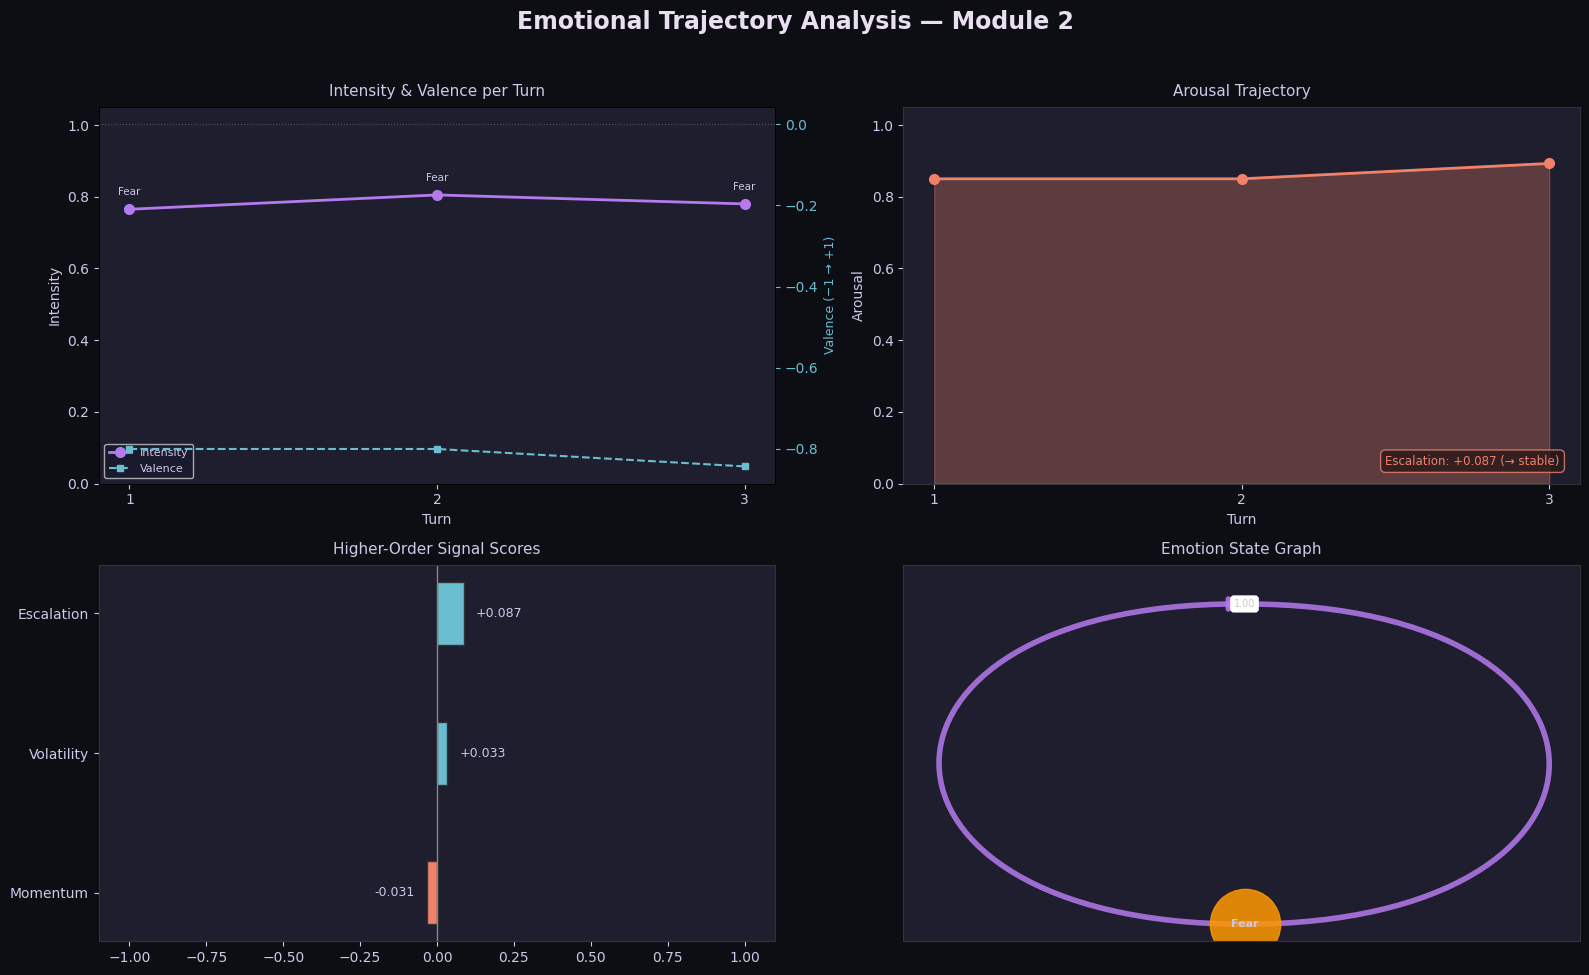

In [12]:
%matplotlib inline
plot_trajectory(signals)

## 8. Transition Matrix — Formatted View

In [13]:
import pandas as pd

states = sorted(signals.transition_matrix.keys())
df_trans = pd.DataFrame(signals.transition_matrix, index=states, columns=states).T
df_trans.index.name = "from \ to"
df_trans.style.background_gradient(cmap="YlOrRd", axis=None).format("{:.2f}")

<>:5: SyntaxWarning: invalid escape sequence '\ '
<>:5: SyntaxWarning: invalid escape sequence '\ '
C:\Users\kapil\AppData\Local\Temp\ipykernel_30856\2233976146.py:5: SyntaxWarning: invalid escape sequence '\ '
  df_trans.index.name = "from \ to"


,Fear
from \ to,
Fear,1.00


## 9. Try Your Own Conversation

Edit the turns below and re-run to compute signals for any multi-turn input.

════════════════════════════════════════════════════════
  EMOTIONAL TRAJECTORY SUMMARY
════════════════════════════════════════════════════════
  Turns analysed     : 4
  Dominant state     : Sadness
  Emotional momentum : -0.2729
  Volatility index   : 0.1814
  Escalation score   : +0.4030

  Emotion sequence   : Joy → Joy → Fear → Sadness

  Turn-by-turn detail:
    T1: [Joy(0.85), Excitement(0.70)]  → Joy  intensity=0.775  valence=+1.000  arousal=0.700
    T2: [Joy(0.60), Nervousness(0.45)]  → Joy  intensity=0.525  valence=+0.229  arousal=0.764
    T3: [Anxiety(0.72), Disappointment(0.55)]  → Fear  intensity=0.635  valence=-0.757  arousal=0.612
    T4: [Sadness(0.80), Grief(0.40)]  → Sadness  intensity=0.600  valence=-0.700  arousal=0.300

  Transition probabilities:
    Fear         → Sadness       p=1.00
    Joy          → Fear          p=0.50
    Joy          → Joy           p=0.50
════════════════════════════════════════════════════════


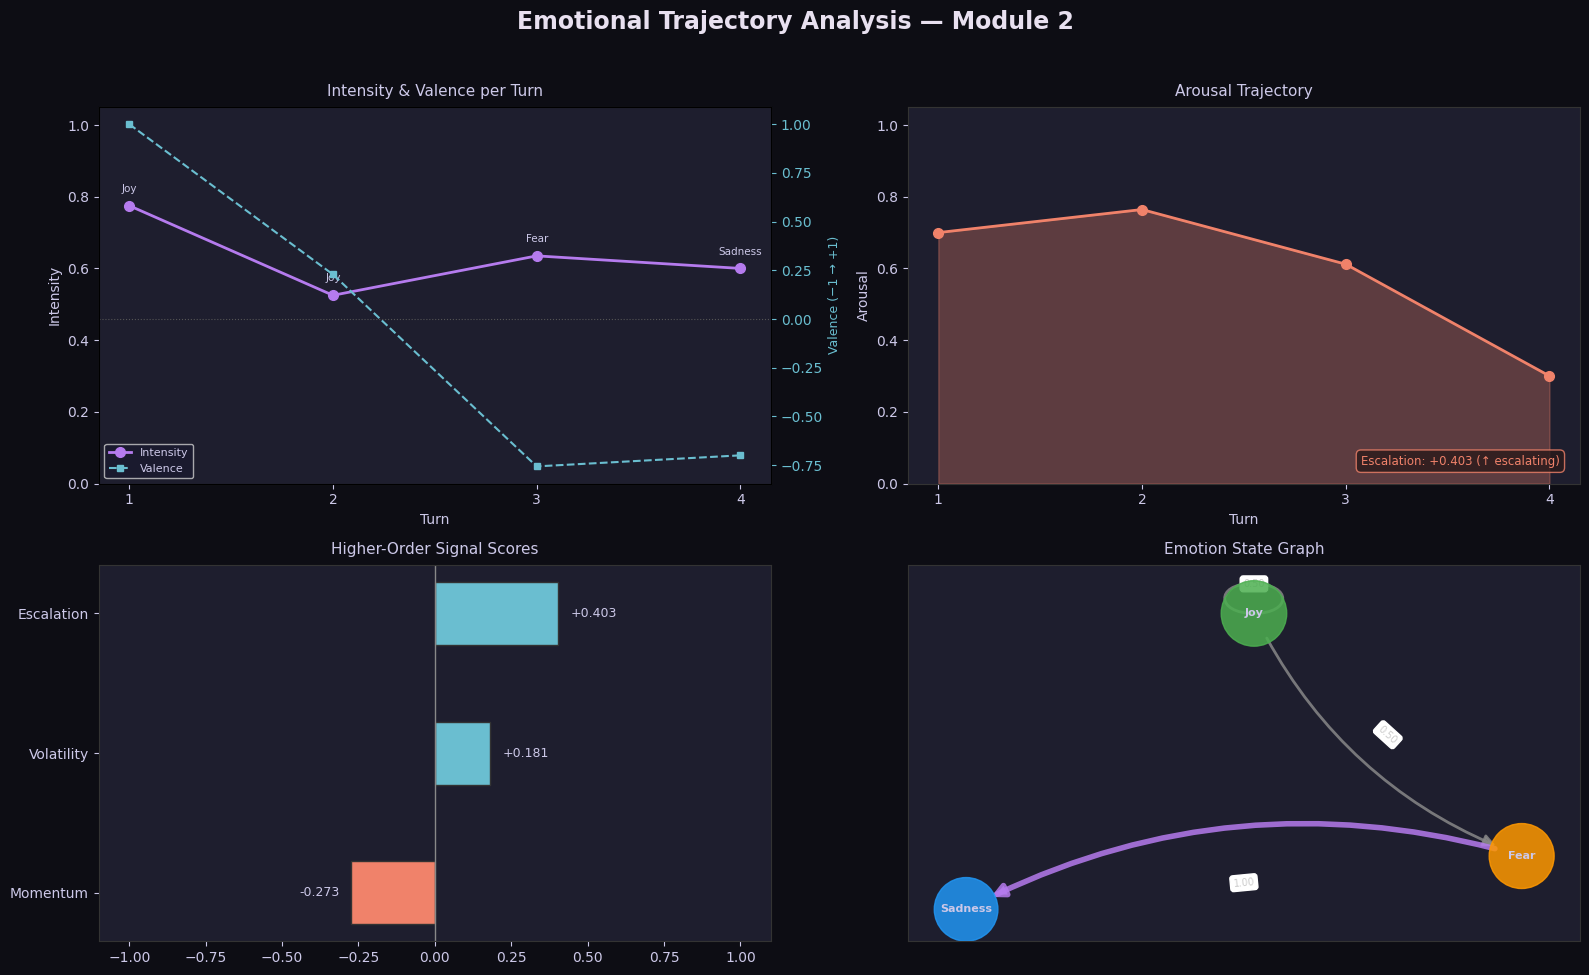

In [14]:
# ── Define your conversation here ─────────────────────────────────────────────
# Format: list of dicts, each dict is one turn.
# Keys are emotion labels (any string — unmapped labels are kept as-is).
# Values are confidence scores in [0, 1] from your RoBERTa model.

custom_conversation = [
    {"Joy": 0.85, "Excitement": 0.70},           # Turn 1
    {"Joy": 0.60, "Nervousness": 0.45},          # Turn 2
    {"Anxiety": 0.72, "Disappointment": 0.55},   # Turn 3
    {"Sadness": 0.80, "Grief": 0.40},            # Turn 4
]

# ── Run the tracker ───────────────────────────────────────────────────────────
custom_tracker = EmotionalTrajectoryTracker()
for turn_emotions in custom_conversation:
    custom_tracker.add_turn(turn_emotions)

custom_signals = custom_tracker.compute()
print(custom_signals.summary())

plot_trajectory(custom_signals)

## 10. Dataset Adapter Usage Examples

In [15]:
# ── GoEmotions (logit/probability vector) ─────────────────────────────────────
goemotion_probs = [0.05] * 28
goemotion_probs[14] = 0.82   # fear
goemotion_probs[19] = 0.61   # nervousness
goemotion_probs[3]  = 0.55   # annoyance

ge_emotions = DatasetAdapters.from_goemotion_logits(goemotion_probs, threshold=0.3)
print("GoEmotions logits →", ge_emotions)

# ── GoEmotions (binary indices) ───────────────────────────────────────────────
ge_idx = DatasetAdapters.from_goemotion_indices([14, 19], score=0.85)
print("GoEmotions indices →", ge_idx)

# ── DailyDialog ───────────────────────────────────────────────────────────────
dd = DatasetAdapters.from_dailydialog(emotion_id=3, intensity=0.80)
print("DailyDialog (fear) →", dd)

# ── MELD ──────────────────────────────────────────────────────────────────────
meld = DatasetAdapters.from_meld(emotion="fear", sentiment="negative")
print("MELD →", meld)

# ── EmpatheticDialogues ───────────────────────────────────────────────────────
empd = DatasetAdapters.from_empathetic("terrified", score=0.9)
print("EmpatheticDialogues →", empd)

GoEmotions logits → {'annoyance': 0.55, 'fear': 0.82, 'nervousness': 0.61}
GoEmotions indices → {'fear': 0.85, 'nervousness': 0.85}
DailyDialog (fear) → {'Fear': 0.8}
MELD → {'fear': 0.75, 'Sadness': 0.2}
EmpatheticDialogues → {'terrified': 0.9}


════════════════════════════════════════════════════════
  EMOTIONAL TRAJECTORY SUMMARY
════════════════════════════════════════════════════════
  Turns analysed     : 5
  Dominant state     : Sadness
  Emotional momentum : -0.0280
  Volatility index   : 0.2135
  Escalation score   : +0.4527

  Emotion sequence   : Joy → Surprise → Fear → Anger → Sadness

  Turn-by-turn detail:
    T1: [joy(0.75), Joy(0.30)]  → Joy  intensity=0.525  valence=+1.000  arousal=0.700
    T2: [surprise(0.75)]  → Surprise  intensity=0.750  valence=+0.200  arousal=0.900
    T3: [fear(0.75), Sadness(0.20)]  → Fear  intensity=0.475  valence=-0.779  arousal=0.734
    T4: [anger(0.75), Sadness(0.20)]  → Anger  intensity=0.475  valence=-0.858  arousal=0.813
    T5: [sadness(0.75), Sadness(0.20)]  → Sadness  intensity=0.475  valence=-0.700  arousal=0.300

  Transition probabilities:
    Anger        → Sadness       p=1.00
    Fear         → Anger         p=1.00
    Joy          → Surprise      p=1.00
    Surprise   

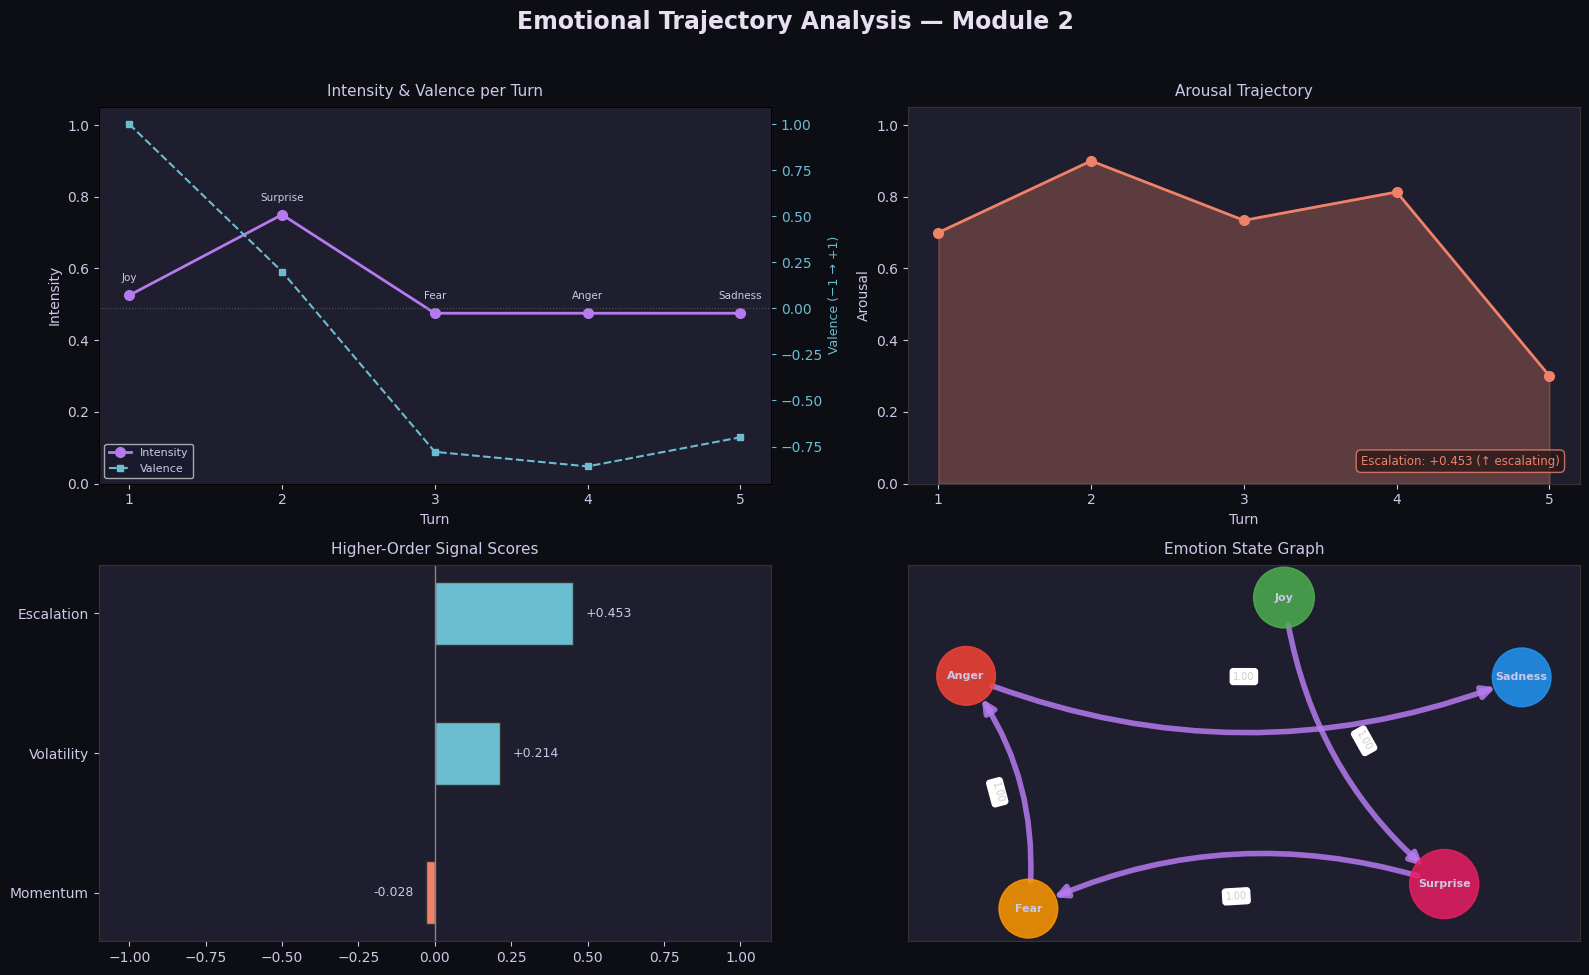

In [16]:
# Example: building a conversation from MELD-style rows
meld_rows = [
    ("joy",       "positive"),
    ("surprise",  "neutral"),
    ("fear",      "negative"),
    ("anger",     "negative"),
    ("sadness",   "negative"),
]

meld_tracker = EmotionalTrajectoryTracker()
for emotion, sentiment in meld_rows:
    meld_tracker.add_turn(DatasetAdapters.from_meld(emotion, sentiment))

meld_signals = meld_tracker.compute()
print(meld_signals.summary())
plot_trajectory(meld_signals)

## 11. Module 3 Integration — Conditioning Prompt Builder

Generates the prompt-level instruction string that Module 3 (Adaptive Dialogue Generator) would prepend to each LLM call, as described in the proposal.

In [17]:
def build_conditioning_prompt(signals: TrajectorySignals) -> str:
    """
    Build the emotion-conditioning instruction for Module 3.

    Returns a string to prepend to the LLM system prompt, e.g.:
    "User emotional trajectory: escalating anxiety → pressure.
     Volatility: high. Respond with validation + grounding tone."
    """
    esc = signals.escalation_score
    vol = signals.volatility_index
    mom = signals.emotional_momentum

    # Trajectory description
    trajectory_str = " → ".join(signals.emotion_sequence)
    if esc > 0.15:
        traj_prefix = "escalating"
    elif esc < -0.15:
        traj_prefix = "de-escalating"
    else:
        traj_prefix = "stable"

    # Volatility label
    if vol > 0.6:
        vol_label = "very high"
    elif vol > 0.35:
        vol_label = "high"
    elif vol > 0.15:
        vol_label = "moderate"
    else:
        vol_label = "low"

    # Tone recommendation
    if esc > 0.2 and vol > 0.3:
        tone = "validation + grounding + emotional de-escalation"
    elif esc > 0.1:
        tone = "empathetic acknowledgement + gentle reframing"
    elif esc < -0.1:
        tone = "reinforcing + warm encouragement"
    elif vol > 0.4:
        tone = "stabilising + calm, consistent reassurance"
    else:
        tone = "neutral + supportive"

    prompt = (
        f"[EMOTIONAL CONTEXT — Module 2 output]\n"
        f"User emotional trajectory: {traj_prefix} {trajectory_str.lower()}.\n"
        f"Dominant state: {signals.dominant_state}. "
        f"Momentum: {signals.emotional_momentum:+.3f}. "
        f"Volatility: {vol_label} ({signals.volatility_index:.3f}). "
        f"Escalation: {signals.escalation_score:+.3f}.\n"
        f"Recommended tone: {tone}.\n"
        f"[END EMOTIONAL CONTEXT]"
    )
    return prompt


# Run on the proposal demo signals
conditioning_prompt = build_conditioning_prompt(signals)
print(conditioning_prompt)

[EMOTIONAL CONTEXT — Module 2 output]
User emotional trajectory: stable fear → fear → fear.
Dominant state: Fear. Momentum: -0.031. Volatility: low (0.033). Escalation: +0.087.
Recommended tone: neutral + supportive.
[END EMOTIONAL CONTEXT]


## 12. Module 1 JSONL Integration

Load the output produced by `module1.infer` (`artifacts/turn_emotions.jsonl`) and feed it directly into the trajectory tracker.

### Expected Module 1 output schema (one line per utterance)
```json
{"dialog_id": "conv_01", "turn_id": 0, "text": "...",
 "scores": {"joy": 0.12, "sadness": 0.05, "anger": 0.03,
             "fear": 0.72, "disgust": 0.02, "surprise": 0.08, "contempt": 0.01},
 "intensity": {"joy": 0.12, ...},
 "active_labels": ["fear"],
 "logits": [...]}
```

The loader groups turns by `dialog_id`, runs each conversation through the tracker,
and returns a `dict[dialog_id → TrajectorySignals]`.

In [18]:
import json as _json
import os
from collections import defaultdict


def load_module1_jsonl(path: str) -> dict:
    """
    Load Module 1 inference output and run Module 2 trajectory analysis.

    Parameters
    ----------
    path : str
        Path to the JSONL file produced by ``module1.infer``
        (e.g. ``artifacts/turn_emotions.jsonl``).

    Returns
    -------
    dict[str, TrajectorySignals]
        Mapping from dialog_id to its computed TrajectorySignals.
    """
    # 1. Parse and group turns by dialog_id
    conversations: dict = defaultdict(list)
    with open(path, "r", encoding="utf-8") as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            row = _json.loads(line)
            conversations[row["dialog_id"]].append(row)

    # Sort each conversation's turns by turn_id
    for did in conversations:
        conversations[did].sort(key=lambda r: r["turn_id"])

    # 2. Feed each turn's Module 1 scores into the tracker.
    #    Module 1 'scores' keys (joy, sadness, anger, fear, disgust,
    #    surprise, contempt) map directly via EMOTION_CLUSTERS.
    results: dict = {}
    for dialog_id, turns in conversations.items():
        tracker = EmotionalTrajectoryTracker()
        for turn in turns:
            # Prefer 'scores'; fall back to 'intensity'; last resort: active_labels
            emotion_scores: dict = (
                turn.get("scores")
                or turn.get("intensity")
                or {label: 1.0 for label in turn.get("active_labels", [])}
            )
            tracker.add_turn(emotion_scores)
        results[dialog_id] = tracker.compute()

    return results


print("load_module1_jsonl() defined.")

load_module1_jsonl() defined.


Loaded 1 conversation(s) from C://Users//kapil//Downloads//final project//final project//artifacts//turn_emotions.jsonl

=== demo1 ===
════════════════════════════════════════════════════════
  EMOTIONAL TRAJECTORY SUMMARY
════════════════════════════════════════════════════════
  Turns analysed     : 3
  Dominant state     : Fear
  Emotional momentum : +0.7157
  Volatility index   : 0.1445
  Escalation score   : -0.4971

  Emotion sequence   : Fear → Fear → Joy

  Turn-by-turn detail:
    T1: [joy(0.08), sadness(0.35), anger(0.02), fear(0.76), disgust(0.01), surprise(0.02), contempt(0.01)]  → Fear  intensity=0.179  valence=-0.639  arousal=0.683
    T2: [joy(0.02), sadness(0.31), anger(0.16), fear(0.69), disgust(0.03), surprise(0.02), contempt(0.10)]  → Fear  intensity=0.191  valence=-0.733  arousal=0.701
    T3: [joy(0.12), sadness(0.05), anger(0.00), fear(0.02), disgust(0.00), surprise(0.02), contempt(0.00)]  → Joy  intensity=0.032  valence=+0.281  arousal=0.634

  Transition probabi

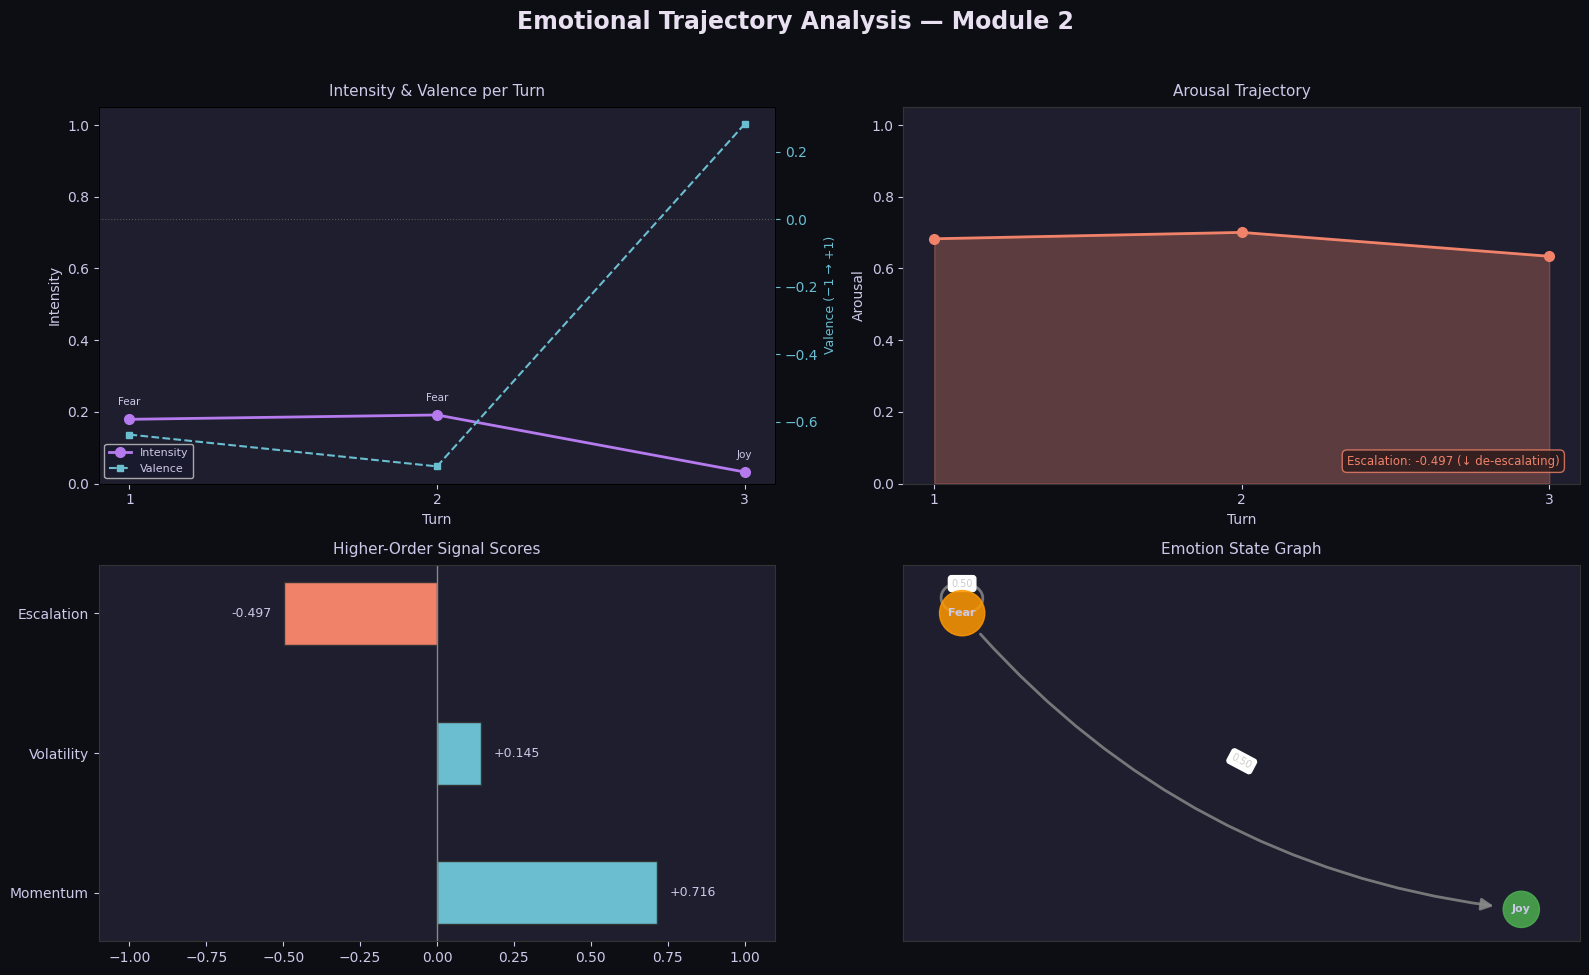

<Figure size 640x480 with 0 Axes>

In [22]:
# ── Point this at your Module 1 output ───────────────────────────────────────
# Default path matches the MODULE1_HANDOFF inference command:
#   python -m module1.infer ... --output_jsonl artifacts/turn_emotions.jsonl
MODULE1_OUTPUT =  "C://Users//kapil//Downloads//final project//final project//artifacts//turn_emotions.jsonl"

if os.path.exists(MODULE1_OUTPUT):
    all_signals = load_module1_jsonl(MODULE1_OUTPUT)
    print(f"Loaded {len(all_signals)} conversation(s) from {MODULE1_OUTPUT}\n")

    for dialog_id, sig in all_signals.items():
        print(f"=== {dialog_id} ===")
        print(sig.summary())
        print()
        plot_trajectory(sig)
        plt.suptitle(f"Emotional Trajectory — {dialog_id}", y=1.01)
        plt.tight_layout()
        plt.show()
else:
    print(
        f"File not found: {MODULE1_OUTPUT}\n\n"
        "Run Module 1 inference first:\n"
        "  python -m module1.infer "
        "--model_dir outputs/module1_goemotions/module1_model "
        "--input_jsonl data/sample_conversations.jsonl "
        "--output_jsonl artifacts/turn_emotions.jsonl"
    )

## 13. Conditioning Prompts from Module 1 Data

Once `all_signals` is populated from the JSONL loader above, generate a
Module 3 conditioning prompt for every conversation in the file.

In [23]:
if 'all_signals' in dir() and all_signals:
    for dialog_id, sig in all_signals.items():
        prompt = build_conditioning_prompt(sig)
        print(f"--- {dialog_id} ---")
        print(prompt)
        print()
else:
    print("Run the JSONL loader cell (Section 12) first.")

--- demo1 ---
[EMOTIONAL CONTEXT — Module 2 output]
User emotional trajectory: de-escalating fear → fear → joy.
Dominant state: Fear. Momentum: +0.716. Volatility: low (0.145). Escalation: -0.497.
Recommended tone: reinforcing + warm encouragement.
[END EMOTIONAL CONTEXT]

